# BrushCue Example: Oval

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/oval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/oval

In [ ]:
!pip install brushcue

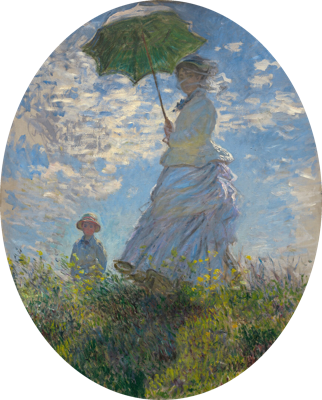

In [1]:
import brushcue
from PIL import Image
import io

input_image_1 = brushcue.composition_monet_women_with_parasol() # insert your own image here
string_constant_2 = brushcue.string_constant("let image_size = vec2<f32>(width, height);\nlet center = image_size * 0.5;\nlet radius = max(center, vec2<f32>(0.0001, 0.0001));\nlet normalized = (position - center) / radius;\n\nif (dot(normalized, normalized) > 1.0) {\n    return vec4<f32>(0.0, 0.0, 0.0, 0.0);\n}\n\nreturn sample(position);\n")
string_constant_3 = brushcue.string_constant("\n\n")
string_constant_4 = brushcue.string_constant("height")
dictionary_create_5 = brushcue.dictionary_create()
string_constant_6 = brushcue.string_constant("width")
input_bounds_7 = brushcue.composition_bounds(input_image_1)
image_height_8 = brushcue.bounds2f_height(input_bounds_7)
image_width_9 = brushcue.bounds2f_width(input_bounds_7)
width_input_10 = brushcue.float_add_to_dictionary(dictionary_create_5, string_constant_6, image_width_9)
height_input_11 = brushcue.float_add_to_dictionary(width_input_10, string_constant_4, image_height_8)
oval_shader_12 = brushcue.composition_spacial_effect_shader(input_image_1, string_constant_2, string_constant_3, 0.0, height_input_11)

ctx = brushcue.Context()
result = oval_shader_12.execute(ctx)
composition = result.as_composition()
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400)) # remove this line for full resolution
img
